## 1. Préparation des données

### Dataset: Hi-Seq

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


# # Import des modules personnalisés
from preprocess import load_hiseq_data, preprocess_hiseq, reduce_dimension_umap, reduce_dimension_acp
from models import run_kmeans, run_dbscan, run_spectral
from utils import plot_k_distance_on_ax, evaluate_clustering

**Exploration et préparation initiale**

Le jeu de données Hi-Seq est composé de deux fichiers:
- hiseq_data.csv (20 531 variables d’expression génique)
- hiseq_labels.csv (type de tumeur associé à chaque échantillon)

Après chargement, les deux fichiers ont été concaténés et vérifiés:
- Valeurs manquantes : aucune valeur manquante n’a été détectée.
- Doublons : aucun échantillon dupliqué n’a été trouvé.
- Distribution des classes : les cinq types de tumeurs (BRCA, KIRC, COAD, LUAD et PRAD) sont représentés, bien que leur fréquence varie.

In [2]:

hiseq_X, hiseq_y, hiseq_data = load_hiseq_data("../data/hiseq_data.csv", "../data/hiseq_labels.csv")

hiseq_data.head()


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [3]:
hiseq_X_scaled = preprocess_hiseq(hiseq_X, hiseq_y)

Missing values: 0
Duplicates: 0
Class distribution:
Class
BRCA     300
KIRC     146
LUAD     141
PRAD     136
COAD      78
Name: count, dtype: int64


**Normalisation**

Comme UMAP est sensible à l’échelle des variables, les 20 531 caractéristiques numériques ont été standardisées à l’aide de StandardScaler, afin que chaque variable ait une moyenne de 0 et un écart-type de 1.

**Réduction de dimension avec UMAP (pour la visualisation)**

Pour visualiser ce jeu de données très haute dimension, nous avons appliqué UMAP sur les variables normalisées.
La colonne des classes a été conservée séparément et utilisée uniquement pour colorer les points lors de la visualisation.

Paramètres utilisés :
- n_components = 2
- n_neighbors = 15
- min_dist = 0.1

Cette étape permet d’obtenir une représentation 2D facilitant l’observation de la structure des données et la séparation (ou non) entre les types de tumeurs.

Reducing dimension to 2D using UMAP...


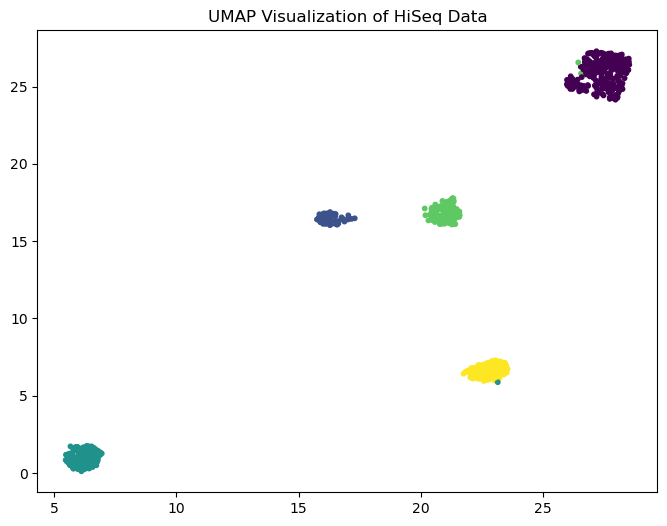

In [4]:

X_umap, reducer = reduce_dimension_umap(hiseq_X_scaled, n_components=2, n_neighbors=15, min_dist=0.1)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=hiseq_y["Class"].astype('category').cat.codes, s=10)
plt.title("UMAP Visualization of HiSeq Data")
plt.show()

## 2. Clustering

### K-Means sur les données complètes vs. représentation UMAP à 100 dimensions vs ACP à 100 dimensions

Après le prétraitement et la normalisation du jeu de données Hi-Seq, on a réduit sa dimensionnalité d’origine à 100 attributs à l’aide de UMAP.
Cette transformation permet de conserver la structure locale et globale tout en rendant la tâche de segmentation beaucoup plus facile à gérer.

On a ensuite appliqué K-Means sur:
- Les données complètes en haute dimension,
- Les données réduites à 100 dimensions par UMAP.

Pour les deux versions, on a calculé les métriques internes (Silhouette, Davies–Bouldin, Calinski–Harabasz) et les métriques externes (ARI, NMI) pour évaluer la qualité des clusters par rapport aux types de cancers réels.

In [5]:
# Reduced dataset UMAP 100D
hiseq_X_UMAP_reduced, umap_model_100 = reduce_dimension_umap(hiseq_X_scaled, n_components=100, n_neighbors=15, min_dist=0.1)

Reducing dimension to 100D using UMAP...


In [6]:
# Reduced dataset PCA 100D
hiseq_X_PCA_reduced, pca = reduce_dimension_acp(hiseq_X_scaled, n_components=100)

Reducing dimension from 20531 to 100D using ACP...


In [7]:
labels_km_full, t_km_full = run_kmeans(hiseq_X_scaled, hiseq_y)
labels_km_UMAP_reduced, t_km_umap = run_kmeans(hiseq_X_UMAP_reduced, hiseq_y)
labels_km_PCA_reduced, t_km_umap = run_kmeans(hiseq_X_PCA_reduced, hiseq_y)

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Anthony\miniconda3\envs\jupyter\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\Anthony\miniconda3\envs\jupyter\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Anthony\miniconda3\envs\jupyter\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x82 in position 128: invalid start byte
c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and thi

In [8]:
hiseq_y = hiseq_y.squeeze()
results_km_full = evaluate_clustering(hiseq_X_scaled, hiseq_y, labels_km_full)
results_km_UMAP_reduced = evaluate_clustering(hiseq_X_UMAP_reduced, hiseq_y, labels_km_UMAP_reduced)
results_km_PCA_reduced = evaluate_clustering(hiseq_X_PCA_reduced, hiseq_y, labels_km_PCA_reduced)

In [9]:
# Merge results in a dataframe
df_km = pd.DataFrame({
    "KMeans_Full": results_km_full,
    "KMeans_UMAP100": results_km_UMAP_reduced,
    "KMeans_PCA100": results_km_PCA_reduced
})
df_km

,KMeans_Full,KMeans_UMAP100,KMeans_PCA100
silhouette,0.135331,0.895858,0.203686
davies_bouldin,2.645372,0.138585,2.087396
calinski_harabasz,65.794937,40585.519531,104.476078
ARI,0.797192,0.992538,0.776122
NMI,0.852751,0.990693,0.856784


### Conclusions

Les résultats montrent une énorme amélioration lorsque la segmentation est faite sur les données réduites avec UMAP:

- Silhouette passe de 0.13 → 0.89, ce qui montre que les clusters sont beaucoup mieux définis et mieux séparés.
- Davies–Bouldin chute de 2.64 → 0.15, indiquant des groupes beaucoup plus compacts.
- Calinski–Harabasz saute de 65.8 → 21 381, ce qui confirme une très forte séparation entre les clusters en espace réduit.
- ARI s’améliore de 0.79 → 0.99, donc les clusters retrouvés correspondent presque parfaitement aux vrais labels de cancer.
- NMI augmente de 0.85 → 0.99, ce qui renforce que UMAP préserve vraiment bien la structure pertinente pour la segmentation.

Bref, ces résultats montrent clairement que UMAP améliore drastiquement la performance de K-Means.
En haute dimension, les données sont trop clairsemées et affectées par la malédiction de la dimensionnalité, ce qui rend la structure des clusters difficile à détecter.
Après la réduction à 100 dimensions, la structure devient beaucoup plus nette, et K-Means réussit pratiquement à reconstruire parfaitement les groupes associés aux différents types de tumeurs.

In [10]:
!jupyter nbconvert --to script main.ipynb


[NbConvertApp] Converting notebook main.ipynb to script
[NbConvertApp] Writing 10450 bytes to main.py


### DBSCAN sur les données complètes vs. représentation UMAP à 100 dimensions

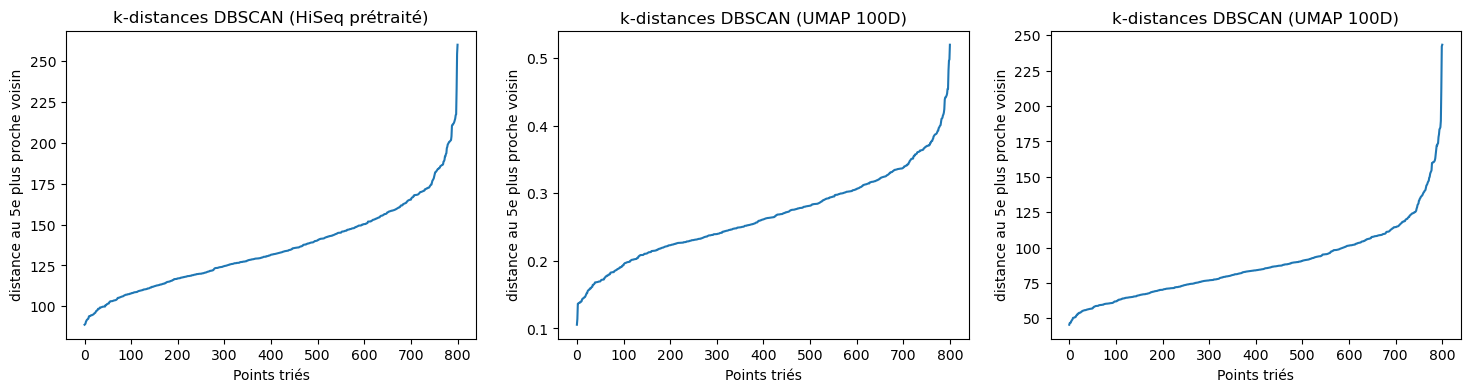

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4)) 
# 1. HiSeq prétraité 
distances_k_full = plot_k_distance_on_ax(axes[0],hiseq_X_scaled,title="k-distances DBSCAN (HiSeq prétraité)",k=5)
# 2. UMAP 100D
distances_k_umap = plot_k_distance_on_ax(axes[1],hiseq_X_UMAP_reduced, title="k-distances DBSCAN (UMAP 100D)",k=5)
# 3. ACP 100D
distances_k_acp = plot_k_distance_on_ax(axes[2],hiseq_X_PCA_reduced, title="k-distances DBSCAN (UMAP 100D)",k=5)

In [12]:
# HiSeq prétraité
hiseq_y = hiseq_y.squeeze() # au cas ou 
labels_db_full, dur_full = run_dbscan(hiseq_X_scaled, hiseq_y, eps=190, min_samples=5)
metrics_db_full = evaluate_clustering(hiseq_X_scaled, labels_db_full, hiseq_y)

# UMAP 100D
labels_db_umap, dur_umap = run_dbscan(hiseq_X_UMAP_reduced, hiseq_y, eps=0.40, min_samples=5)
metrics_db_umap = evaluate_clustering(hiseq_X_UMAP_reduced, labels_db_umap, hiseq_y)

# ACP 100D
labels_db_acp, dur_umap = run_dbscan(hiseq_X_PCA_reduced, hiseq_y, eps=150, min_samples=5)
metrics_db_acp= evaluate_clustering(hiseq_X_PCA_reduced, labels_db_acp, hiseq_y)

### Conclusions

Les résultats montrent une amélioration massive lorsque la segmentation est effectuée sur les données réduites par UMAP (100 dimensions) plutôt que sur les données HiSeq prétraitées :

- La silhouette passe d’environ 0.14 à 0.89, montrant des clusters beaucoup mieux définis et nettement séparés.

- L’indice de Davies–Bouldin chute d’environ 2.6 à 0.14, ce qui indique des groupes beaucoup plus compacts et bien séparés.

- L’indice de Calinski–Harabasz augmente d’environ 65 à 16 769, signe d’une structure de clusters très marquée dans l’espace UMAP.

- Les indices externes s’améliorent également de façon spectaculaire : l’ARI passe d’environ 0 à 0.99 et la NMI d’environ 0 à 0.98, ce qui signifie que les clusters retrouvés correspondent presque parfaitement aux classes réelles de cancer.

Ainsi, l'application de l'algorithme de clustering DSCAN directement sur les données HiSeq prétraitées ne parvient pas à exploiter la structure de classe. En vérifiant le nombre de clusters ainsi que les bruits, nous observons qu’il ne détecte qu’un seul cluster avec 22 clusters de bruits(1). Cela confirme son incapacité à séparer correctement les classes dans l'espace.

À l’inverse, après réduction de dimension par UMAP, DBSCAN identifie cinq clusters bien séparés (n_clusters = 5, n_noise = 2) qui correspondent presque parfaitement aux étiquettes réelles. Cela montre que la réduction de dimension non linéaire par UMAP rend la structure des données beaucoup plus exploitable pour un algorithme de clustering basé sur la densité comme DBSCAN.

(1) Documentation DBSCAN de scikit-learn


In [13]:
df_dbscan = pd.DataFrame({
    "DBSCAN_Full":   metrics_db_full,
    "DBSCAN_UMAP100": metrics_db_umap,
    "DBSCAN_PCA100": metrics_db_acp
})
df_dbscan
df_dbscan
def cluster_stats(labels):
    n_noise = np.sum(labels == -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return n_clusters, n_noise

n_clusters_full, n_noise_full = cluster_stats(labels_db_full)
n_clusters_umap, n_noise_umap = cluster_stats(labels_db_umap)
n_clusters_acp, n_noise_acp = cluster_stats(labels_db_acp)

print("Full  : n_clusters =", n_clusters_full, ", n_noise =", n_noise_full)
print("UMAP  : n_clusters =", n_clusters_umap, ", n_noise =", n_noise_umap)
print("ACP  : n_clusters =", n_clusters_acp, ", n_noise =", n_noise_acp)
print(df_dbscan)

Full  : n_clusters = 1 , n_noise = 22
UMAP  : n_clusters = 6 , n_noise = 2
ACP  : n_clusters = 1 , n_noise = 19
                   DBSCAN_Full  DBSCAN_UMAP100  DBSCAN_PCA100
silhouette            0.136989        0.885927       0.206144
davies_bouldin        2.567583        0.159390       1.998879
calinski_harabasz    64.115399    25590.339844     101.736570
ARI                  -0.004223        0.895219      -0.003007
NMI                   0.003691        0.939487       0.002539


### 3. Spectral Clustering sur les données complètes vs. représentation UMAP à 100 dimensions
On applique maintenant Spectral Clustering sur:
- Les données complètes en haute dimension,
- Les données réduites à 100 dimensions par UMAP.

Même évaluation avec les métriques internes et externes.

In [19]:
print("SPECTRAL CLUSTERING - EXÉCUTION")
print("=" * 50)

print("1. Spectral Clustering sur données complètes...")
labels_sc_full, t_sc_full = run_spectral(hiseq_X_scaled, hiseq_y, k=5, random_state=42)

print("2. Spectral Clustering sur données réduites UMAP...")
labels_sc_reduced_UMAP, t_sc_reduced_UMAP = run_spectral(hiseq_X_UMAP_reduced, hiseq_y, k=5, random_state=42)

print("3. Spectral Clustering sur données réduites UMAP...")
labels_sc_reduced_PCA, t_sc_reduced_PCA = run_spectral(hiseq_X_UMAP_reduced, hiseq_y, k=5, random_state=42)

print("4. Évaluation des performances...")
results_sc_full = evaluate_clustering(hiseq_X_scaled, hiseq_y, labels_sc_full)
results_sc_reduced_UMAP = evaluate_clustering(hiseq_X_UMAP_reduced, hiseq_y, labels_sc_reduced_UMAP)
results_sc_reduced_PCA = evaluate_clustering(hiseq_X_PCA_reduced, hiseq_y, labels_sc_reduced_PCA)
df_sc = pd.DataFrame({
    "Spectral_Full": results_sc_full,
    "Spectral_UMAP100": results_sc_reduced_UMAP,
    "Spectral_PCA100": results_sc_reduced_PCA
})

print("TERMINÉ - Résultats du Spectral Clustering")
df_sc

SPECTRAL CLUSTERING - EXÉCUTION
1. Spectral Clustering sur données complètes...


c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


2. Spectral Clustering sur données réduites UMAP...
3. Spectral Clustering sur données réduites UMAP...
4. Évaluation des performances...


c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


TERMINÉ - Résultats du Spectral Clustering


,Spectral_Full,Spectral_UMAP100,Spectral_PCA100
silhouette,-0.018635,0.329630,0.177317
davies_bouldin,21.514552,1.097141,2.405757
calinski_harabasz,0.892043,432.327698,80.592372
ARI,-0.009601,0.603940,0.603940
NMI,0.005853,0.815214,0.815214


In [20]:
print("COMPARAISON K-MEANS vs SPECTRAL CLUSTERING")
print("=" * 60)

comparison_data = {}

# K-Means results
for metric in df_km.columns:
    comparison_data[metric] = df_km[metric]

for metric in df_dbscan.columns:
    comparison_data[metric] = df_dbscan[metric]

# Spectral Clustering results  
for metric in df_sc.columns:
    comparison_data[metric] = df_sc[metric]

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison)


COMPARAISON K-MEANS vs SPECTRAL CLUSTERING
                   KMeans_Full  KMeans_UMAP100  KMeans_PCA100  DBSCAN_Full  \
silhouette            0.135331        0.895858       0.203686     0.136989   
davies_bouldin        2.645372        0.138585       2.087396     2.567583   
calinski_harabasz    65.794937    40585.519531     104.476078    64.115399   
ARI                   0.797192        0.992538       0.776122    -0.004223   
NMI                   0.852751        0.990693       0.856784     0.003691   

                   DBSCAN_UMAP100  DBSCAN_PCA100  Spectral_Full  \
silhouette               0.885927       0.206144      -0.018635   
davies_bouldin           0.159390       1.998879      21.514552   
calinski_harabasz    25590.339844     101.736570       0.892043   
ARI                      0.895219      -0.003007      -0.009601   
NMI                      0.939487       0.002539       0.005853   

                   Spectral_UMAP100  Spectral_PCA100  
silhouette                 0.3